In [1]:
import numpy as np
import matplotlib.pylab as pl
import ot
import ot.plot

In [2]:
# Generate data
n = 100
x = np.arange(n, dtype=np.float64)

# Gaussian distribution
a = ot.datasets.make_1D_gauss(n, m=20, s=5)
b = ot.datasets.make_1D_gauss(n, m=60, s=10)

# loss matrix
M = ot.dist(x.reshape((n, 1)), x.reshape((n, 1)))
M /= M.max()

## Solve EMD

(<Axes: >, <Axes: >, <Axes: >)

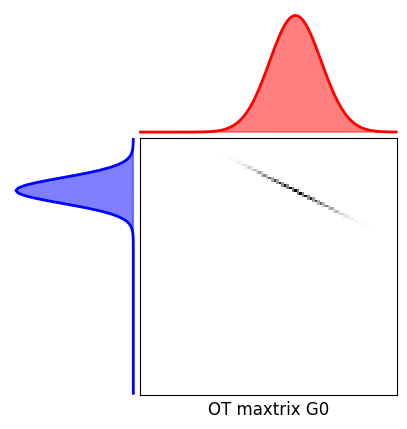

In [3]:
G0 = ot.emd(a, b, M)

pl.figure(1, figsize=(5, 5))
ot.plot.plot1D_mat(a, b, G0, "OT maxtrix G0")

## Solve EMD with Frobenius norm regularization

It.  |Loss        |Relative loss|Absolute loss
------------------------------------------------
    0|1.760578e-01|0.000000e+00|0.000000e+00
    1|1.669467e-01|5.457501e-02|9.111116e-03
    2|1.665639e-01|2.298130e-03|3.827855e-04
    3|1.664378e-01|7.572776e-04|1.260396e-04
    4|1.664077e-01|1.811855e-04|3.015066e-05
    5|1.663912e-01|9.936787e-05|1.653393e-05
    6|1.663852e-01|3.555826e-05|5.916369e-06
    7|1.663814e-01|2.305693e-05|3.836245e-06
    8|1.663785e-01|1.760450e-05|2.929009e-06
    9|1.663767e-01|1.078011e-05|1.793559e-06
   10|1.663751e-01|9.525192e-06|1.584755e-06
   11|1.663737e-01|8.396466e-06|1.396951e-06
   12|1.663727e-01|6.086938e-06|1.012700e-06
   13|1.663720e-01|4.042609e-06|6.725769e-07
   14|1.663713e-01|4.160914e-06|6.922568e-07
   15|1.663707e-01|3.823502e-06|6.361187e-07
   16|1.663702e-01|3.022440e-06|5.028438e-07
   17|1.663697e-01|3.181249e-06|5.292634e-07
   18|1.663692e-01|2.698532e-06|4.489527e-07
   19|1.663687e-01|3.258253e-06|5.420712e-07
It. 

(<Axes: >, <Axes: >, <Axes: >)

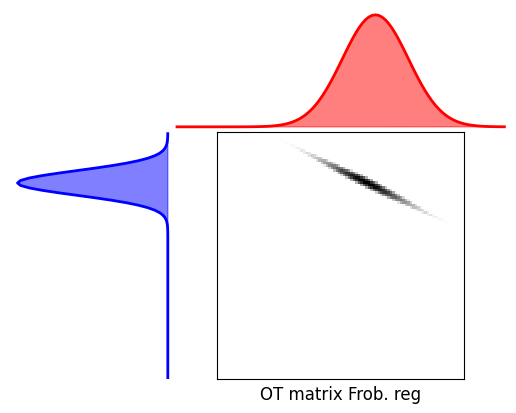

In [11]:
def f(G):
  return 0.5 * np.sum(G**2)

def df(G):
  return G

reg = 1e-1
Gl2 = ot.optim.cg(a, b, M, reg, f, df, verbose=True)

pl.figure(2)
ot.plot.plot1D_mat(a, b, Gl2, "OT matrix Frob. reg")

## Solve EMD with entropic regularization

It.  |Loss        |Relative loss|Absolute loss
------------------------------------------------
    0|1.692289e-01|0.000000e+00|0.000000e+00
    1|1.617643e-01|4.614437e-02|7.464513e-03
    2|1.612633e-01|3.106799e-03|5.010127e-04
    3|1.611082e-01|9.629290e-04|1.551358e-04
    4|1.610170e-01|5.663078e-04|9.118518e-05
    5|1.609974e-01|1.221022e-04|1.965813e-05
    6|1.609928e-01|2.837157e-05|4.567618e-06
    7|1.609872e-01|3.465323e-05|5.578727e-06
    8|1.609862e-01|6.378786e-06|1.026896e-06
    9|1.609810e-01|3.222223e-05|5.187167e-06
   10|1.609638e-01|1.070981e-04|1.723891e-05
   11|1.609578e-01|3.716994e-05|5.982791e-06
   12|1.609478e-01|6.214305e-05|1.000179e-05
   13|1.609476e-01|8.097654e-07|1.303298e-07
   14|1.609332e-01|8.993005e-05|1.447273e-05
   15|1.609212e-01|7.430192e-05|1.195676e-05
   16|1.609137e-01|4.688457e-05|7.544369e-06
   17|1.609060e-01|4.746891e-05|7.638033e-06
   18|1.608892e-01|1.046687e-04|1.684006e-05
   19|1.608785e-01|6.617790e-05|1.064660e-05
It. 

(<Axes: >, <Axes: >, <Axes: >)

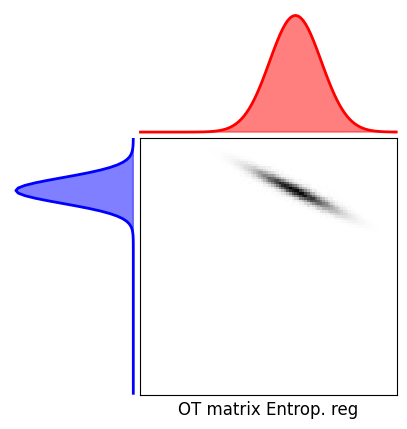

In [8]:
def f(G):
  return np.sum(G * np.log(G))

def df(G):
  return np.log(G) + 1.0

reg = 1e-3

Ge = ot.optim.cg(a, b, M, reg, f, df, verbose=True)

pl.figure(3, figsize=(5, 5))
ot.plot.plot1D_mat(a, b, Ge, "OT matrix Entrop. reg")

## Solve EMD with Forbenius norm + entropic regularization

It.  |Loss        |Relative loss|Absolute loss
------------------------------------------------
    0|1.693084e-01|0.000000e+00|0.000000e+00
    1|1.610202e-01|5.147342e-02|8.288260e-03
    2|1.610179e-01|1.406304e-05|2.264402e-06
    3|1.610174e-01|3.352083e-06|5.397436e-07
    4|1.610174e-01|0.000000e+00|0.000000e+00


/Users/nganga/miniconda3/envs/ot/lib/python3.10/site-packages/ot/bregman/_sinkhorn.py:666: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


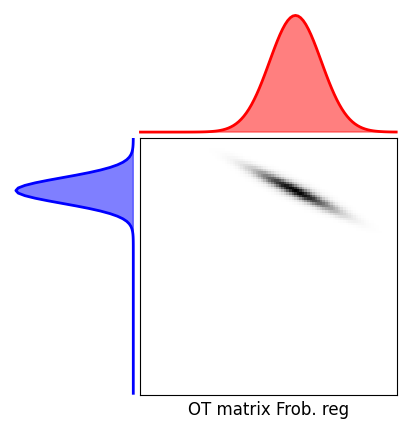

In [12]:
def f(G):
  return 0.5 * np.sum(G**2)

def df(G):
  return G

reg1 = 1e-3
reg2 = 1e-1

Gel2 = ot.optim.gcg(a, b, M, reg1, reg2, f, df, verbose=True)

pl.figure(4, figsize=(5, 5))
ot.plot.plot1D_mat(a, b, Gel2, "OT matrix Frob. reg")
pl.show()

Text(0.5, 1.0, 'Entropic + Frobenius reg.')

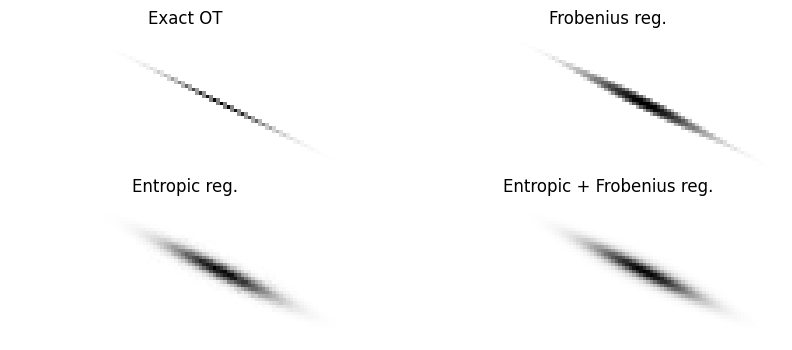

In [13]:
# Comparison of the OT matrices
nvisu = 40

pl.figure(3, figsize=(10, 4))

pl.subplot(2, 2, 1)
pl.imshow(G0[:nvisu, :], cmap="gray_r")
pl.axis("off")
pl.title("Exact OT")

pl.subplot(2, 2, 2)
pl.imshow(Gl2[:nvisu, :], cmap="gray_r")
pl.axis("off")
pl.title("Frobenius reg.")

pl.subplot(2, 2, 3)
pl.imshow(Ge[:nvisu, :], cmap="gray_r")
pl.axis("off")
pl.title("Entropic reg.")

pl.subplot(2, 2, 4)
pl.imshow(Gel2[:nvisu, :], cmap="gray_r")
pl.axis("off")
pl.title("Entropic + Frobenius reg.")